# 02 — Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand the statistical properties, behavioral patterns, and relationships within the IEEE-CIS Fraud Detection dataset.

Unlike the previous notebook, which focused on understanding the dataset structure, this notebook investigates how fraudulent transactions differ from legitimate ones. The insights obtained here will guide:

- Feature engineering
- Graph construction
- Baseline machine learning models
- Graph Neural Network design

Special attention is given to patterns that can later be represented as graph entities and relationships.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from pathlib import Path
from IPython.display import display

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:
# Load Project Configuration

CONFIG_PATH = PROJECT_ROOT / "configs" / "data_config.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

print("Configuration loaded successfully")
print(CONFIG_PATH)

Configuration loaded successfully
/Users/airm2/Desktop/My ML Material/graph-fraud-ai/configs/data_config.yaml


In [3]:
# Load dataset using project pipeline

from src.data.loader import load_ieee_dataset

print("="*70)
print("Loading IEEE-CIS dataset...")
print("="*70)

df = load_ieee_dataset()

print("\nDataset loaded successfully")
print("Merged Dataset Shape:", df.shape)

df.head()

Loading IEEE-CIS dataset...
Loading transaction dataset...
Loading identity dataset...

Transaction shape:
(590540, 394)

Identity shape:
(144233, 41)

Merging datasets...

Merged dataset shape:
(590540, 434)

Dataset loaded successfully
Merged Dataset Shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [4]:
# Dataset is already merged by src/data/loader.py

print("Using merged dataset from project data pipeline.")

df.head()

Using merged dataset from project data pipeline.


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [5]:
# Dataset Information

print("="*70)
print("Merged Dataset Information")
print("="*70)

display(df.head())

display(df.info())

display(df.describe().T)

Merged Dataset Information


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


None

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
id_22,5169.0,1.600271e+01,6.897665e+00,10.000,14.000,14.000,14.00,4.400000e+01
id_24,4747.0,1.280093e+01,2.372447e+00,11.000,11.000,11.000,15.00,2.600000e+01
id_25,5132.0,3.296089e+02,9.746109e+01,100.000,321.000,321.000,371.00,5.480000e+02
id_26,5163.0,1.490703e+02,3.210199e+01,100.000,119.000,149.000,169.00,2.160000e+02


# 7. Transaction Amount Analysis

Transaction amount is one of the strongest indicators of fraudulent behaviour. In this section, we explore its statistical distribution, identify extreme values, and compare fraudulent transactions with legitimate ones.

Objectives:

- Examine the overall distribution of transaction amounts.
- Compare fraud and non-fraud transactions.
- Detect outliers.
- Assess whether transformation may be necessary before modelling.




TRANSACTION AMOUNT ANALYSIS
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


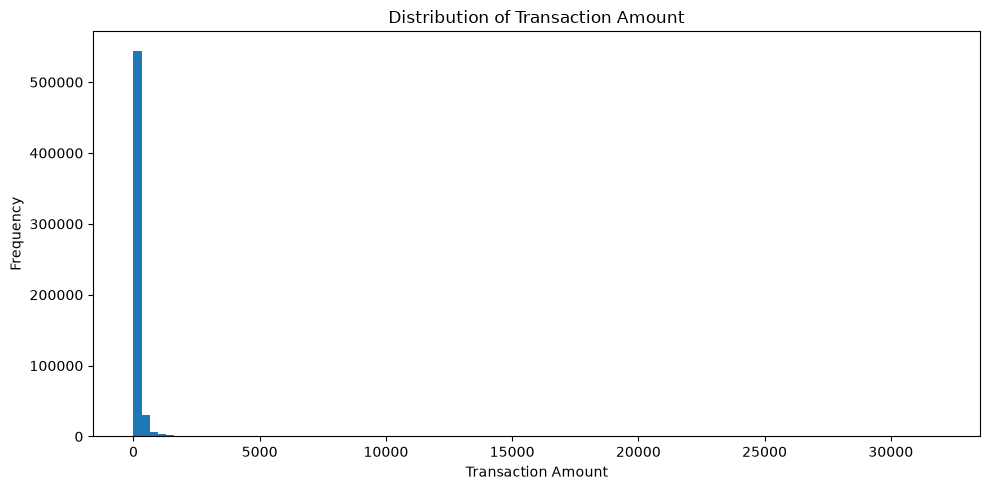

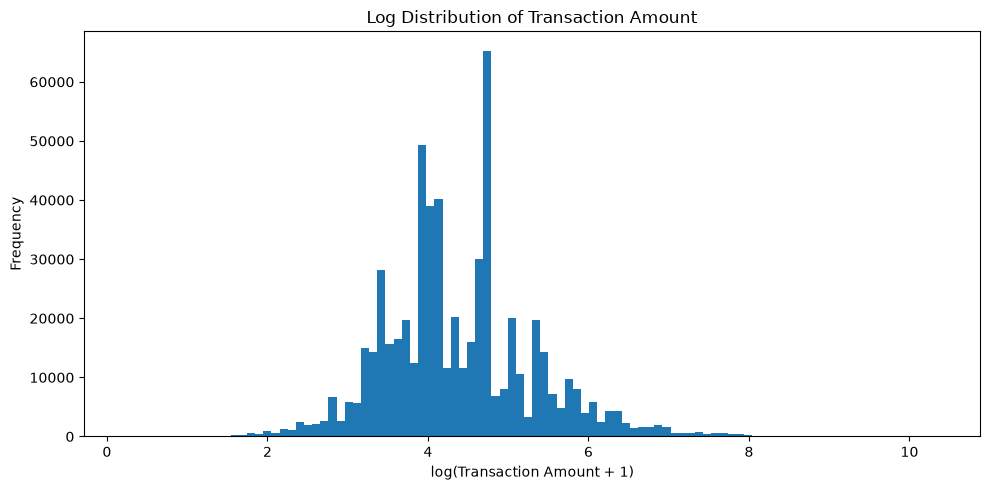

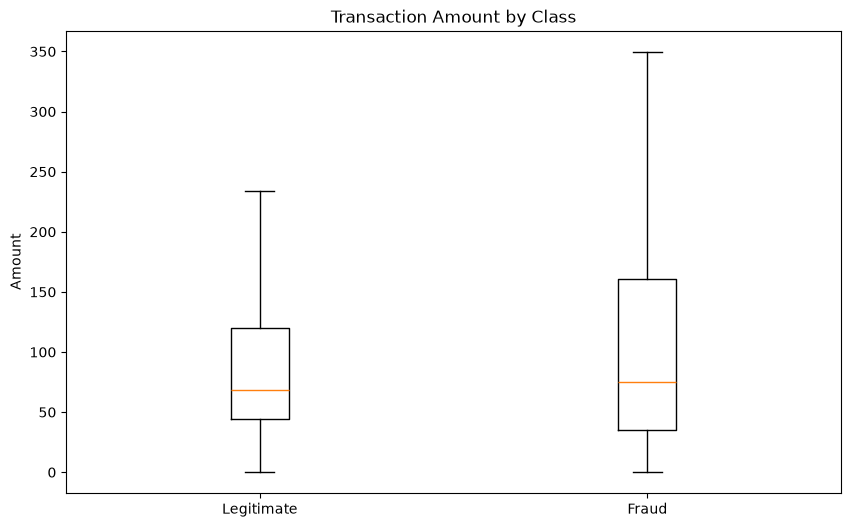

In [6]:
print("=" * 70)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 70)

print(df["TransactionAmt"].describe())

plt.figure(figsize=(10,5))
plt.hist(df["TransactionAmt"], bins=100)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(np.log1p(df["TransactionAmt"]), bins=100)
plt.title("Log Distribution of Transaction Amount")
plt.xlabel("log(Transaction Amount + 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

fraud_amt = df[df["isFraud"] == 1]["TransactionAmt"]
legit_amt = df[df["isFraud"] == 0]["TransactionAmt"]

plt.figure(figsize=(10,6))
plt.boxplot(
    [legit_amt, fraud_amt],
    tick_labels=["Legitimate", "Fraud"],
    showfliers=False
)
plt.title("Transaction Amount by Class")
plt.ylabel("Amount")
plt.show()

# 8. Time-Based Analysis

Transaction timing often reveals hidden fraud patterns. This section investigates the temporal behaviour of transactions using the `TransactionDT` feature.

TIME ANALYSIS


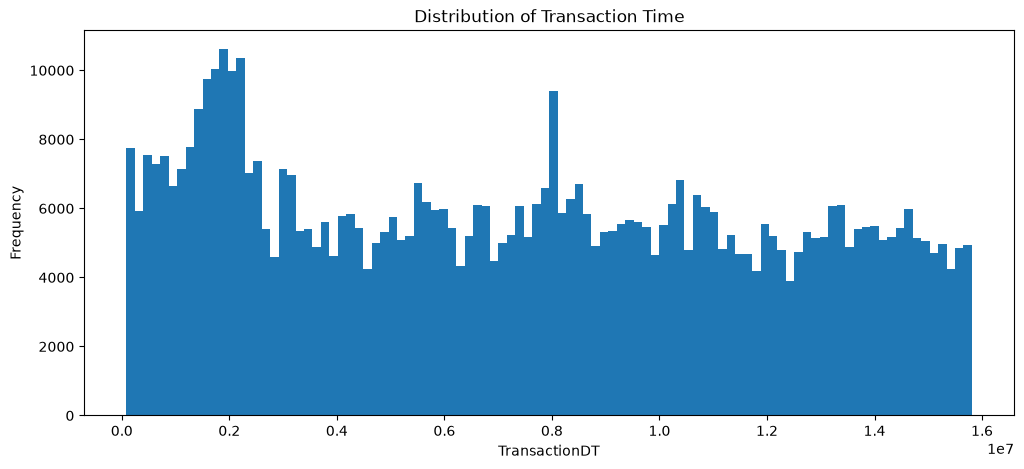

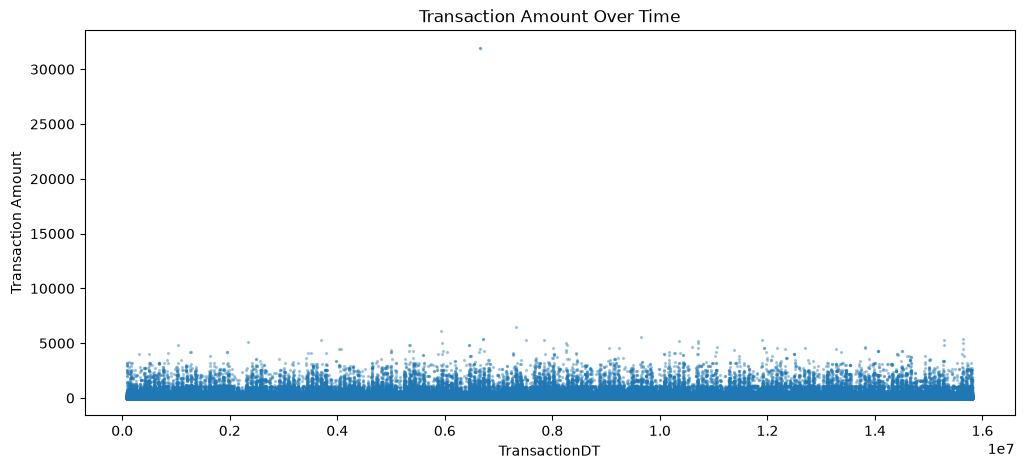

In [7]:
print("="*70)
print("TIME ANALYSIS")
print("="*70)

plt.figure(figsize=(12,5))
plt.hist(df["TransactionDT"], bins=100)
plt.title("Distribution of Transaction Time")
plt.xlabel("TransactionDT")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(12,5))

plt.scatter(
    df["TransactionDT"],
    df["TransactionAmt"],
    s=2,
    alpha=0.3
)

plt.title("Transaction Amount Over Time")

plt.xlabel("TransactionDT")

plt.ylabel("Transaction Amount")

plt.show()

# 9. Product Code Analysis

The `ProductCD` feature categorises transaction products. Understanding how fraud varies across product categories may reveal important behavioural patterns.

,count,sum,Fraud Rate
ProductCD,,,
C,68519,8008,0.116873
H,33024,1574,0.047662
R,37699,1426,0.037826
S,11628,686,0.058996
W,439670,8969,0.020399


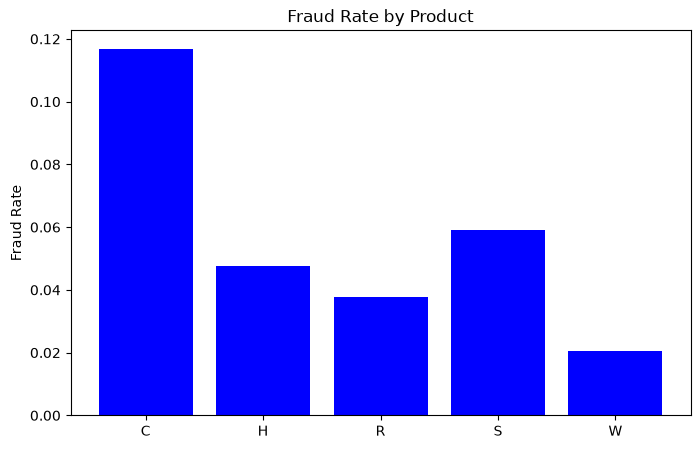

In [8]:
product_summary = (
    df.groupby("ProductCD")["isFraud"]
      .agg(["count","sum","mean"])
      .rename(columns={"mean":"Fraud Rate"})
)

display(product_summary)

plt.figure(figsize=(8,5))

plt.bar(
    product_summary.index.astype(str),
    product_summary["Fraud Rate"]
)
# color
plt.bar(
    product_summary.index.astype(str),
    product_summary["Fraud Rate"],
    color="blue"
)
plt.title("Fraud Rate by Product")

plt.ylabel("Fraud Rate")

plt.show()

# 10. Card Feature Analysis

Payment card attributes provide valuable information for identifying suspicious behaviour. This section explores the distribution of card-related variables and their association with fraud.

card1


card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
12695     7091
12544     6773
6019      6771
2803      6141
7585      5334
Name: count, dtype: int64

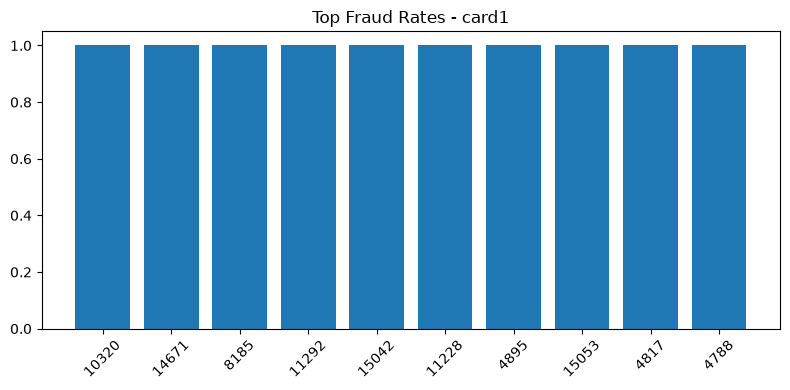

card2


card2
321.0    48935
111.0    45191
555.0    41995
490.0    38145
583.0    21803
170.0    18214
194.0    16938
545.0    16355
360.0    15190
514.0    14541
Name: count, dtype: int64

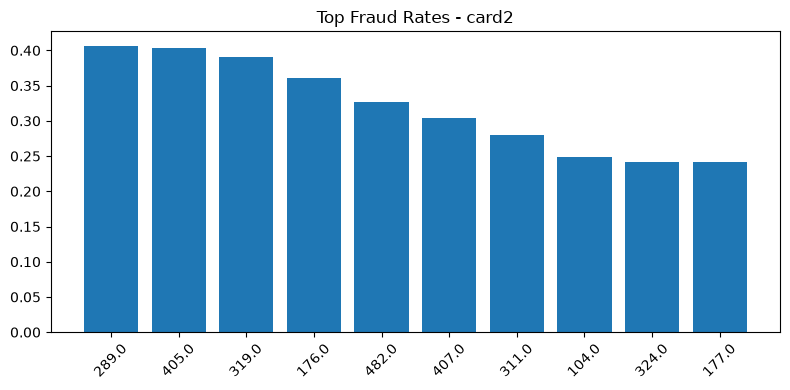

card3


card3
150.0    521287
185.0     56346
106.0      1571
NaN        1565
144.0      1252
146.0      1252
117.0       962
143.0       899
119.0       750
102.0       460
Name: count, dtype: int64

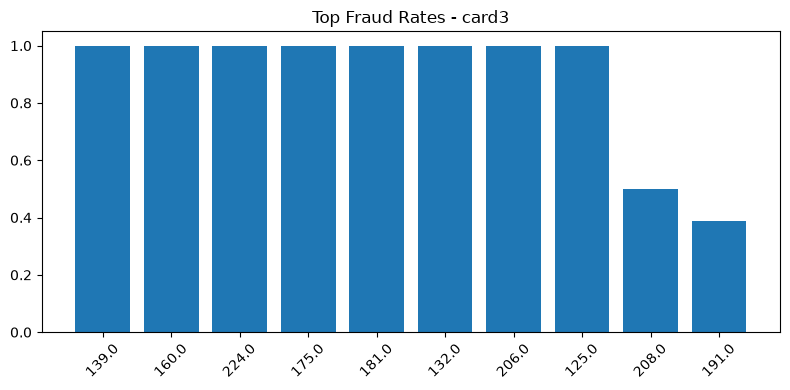

card4


card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

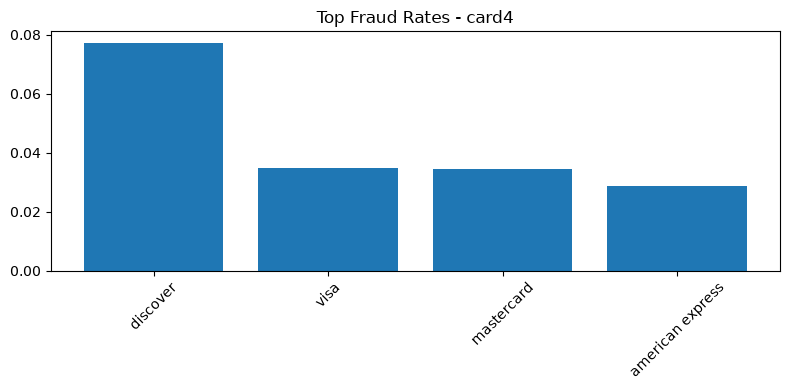

card5


card5
226.0    296546
224.0     81513
166.0     57140
102.0     29105
117.0     25941
138.0     19737
195.0     16945
137.0     11720
126.0     10298
219.0      9924
Name: count, dtype: int64

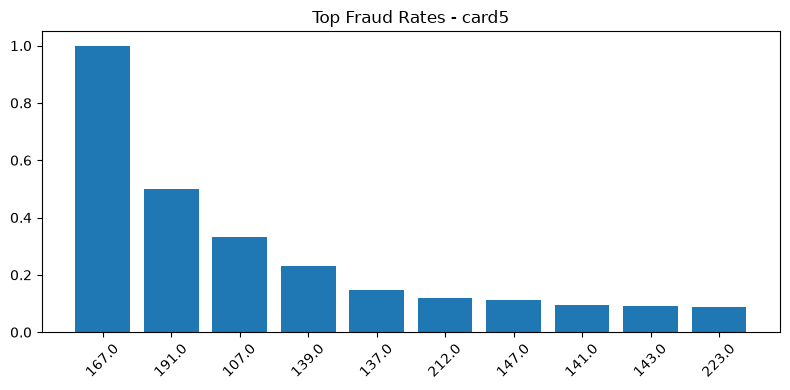

card6


card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

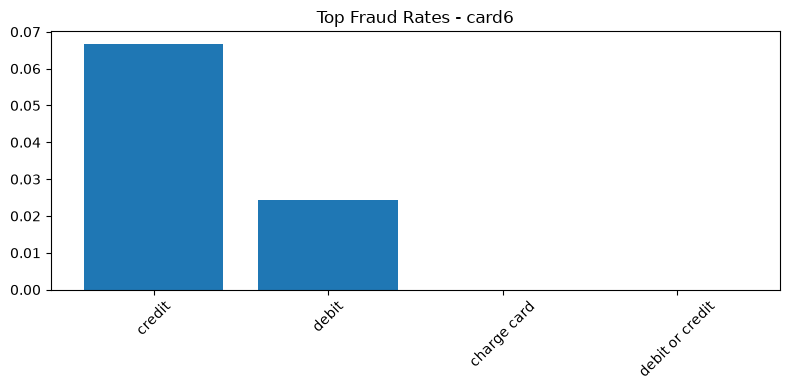

In [9]:
card_columns = [
    "card1", "card2", "card3", "card4", "card5", "card6"
]

for col in card_columns:
    print("="*60)

    print(col)

    display(df[col].value_counts(dropna=False).head(10))

    fraud_rate = (
        df.groupby(col)["isFraud"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(8,4))

    plt.bar(
        fraud_rate.index.astype(str),
        fraud_rate.values
    )

    plt.title(f"Top Fraud Rates - {col}")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# 11. Address Analysis

Regional identifiers (`addr1` and `addr2`) may reveal geographical fraud concentrations. These attributes can later become graph features or location-based nodes depending on modelling decisions.

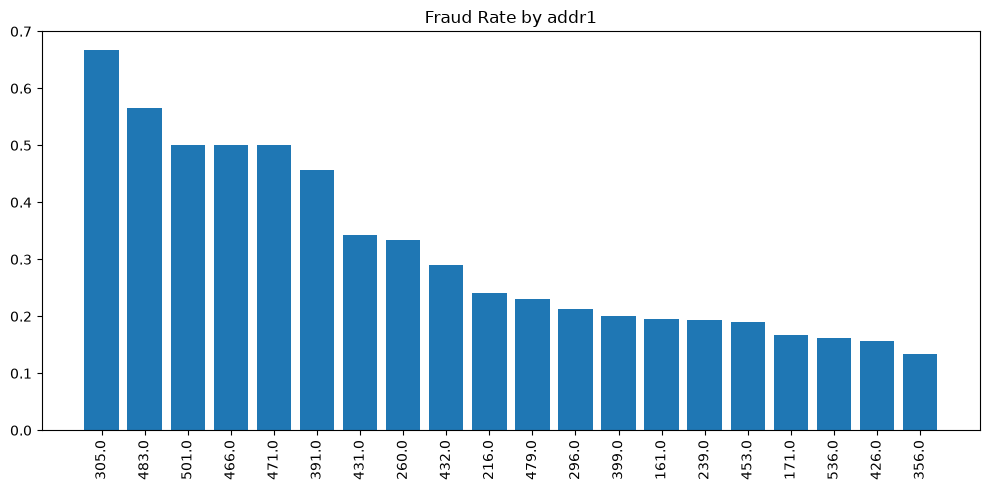

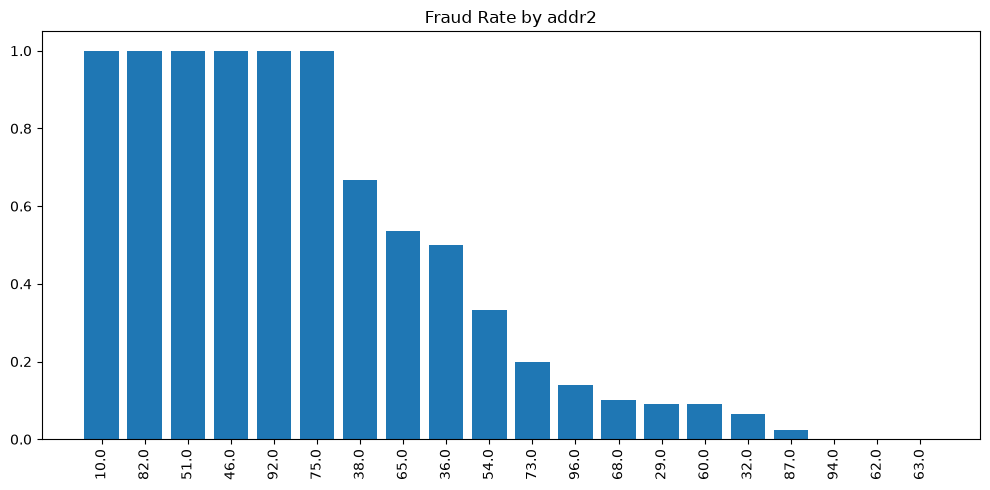

In [10]:
address_cols = ["addr1", "addr2"]

for col in address_cols:

    fraud_rate = (
        df.groupby(col)["isFraud"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10,5))

    plt.bar(
        fraud_rate.index.astype(str),
        fraud_rate.values
    )

    plt.title(f"Fraud Rate by {col}")

    plt.xticks(rotation=90)

    plt.tight_layout()

    plt.show()


# 12. Email Domain Analysis 

Email domains provide additional contextual information about customers and may reveal behavioural similarities between fraudulent accounts.

This section evaluates both purchaser and recipient email domains.

,count,sum,Fraud Rate
P_emaildomain,,,
protonmail.com,76,31,0.407895
mail.com,559,106,0.189624
outlook.es,438,57,0.130137
aim.com,315,40,0.126984
outlook.com,5096,482,0.094584
hotmail.es,305,20,0.065574
live.com.mx,749,41,0.054740
hotmail.com,45250,2396,0.052950
gmail.com,228355,9943,0.043542


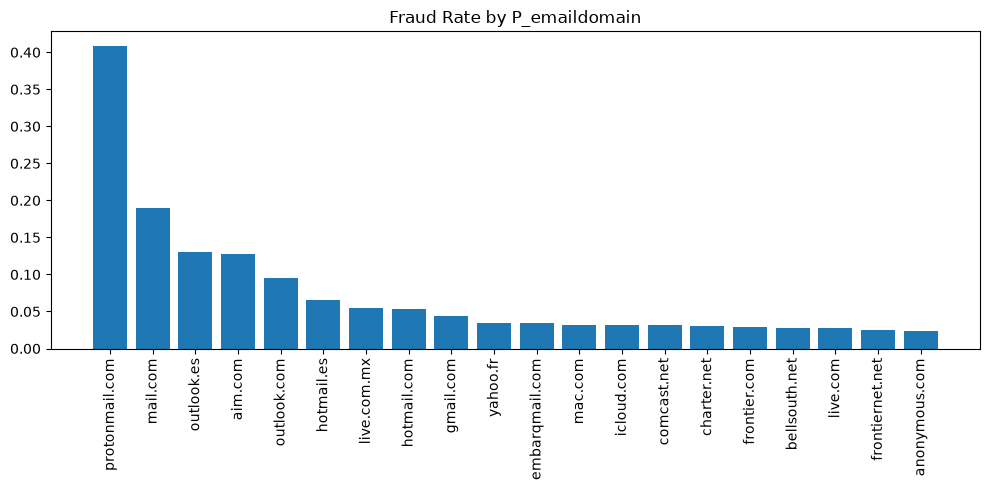

,count,sum,Fraud Rate
R_emaildomain,,,
protonmail.com,41,39,0.951220
mail.com,122,46,0.377049
netzero.net,9,2,0.222222
outlook.com,2507,414,0.165138
outlook.es,433,57,0.131640
icloud.com,1398,180,0.128755
gmail.com,57147,6811,0.119184
hotmail.com,27509,2140,0.077793
earthlink.net,79,6,0.075949


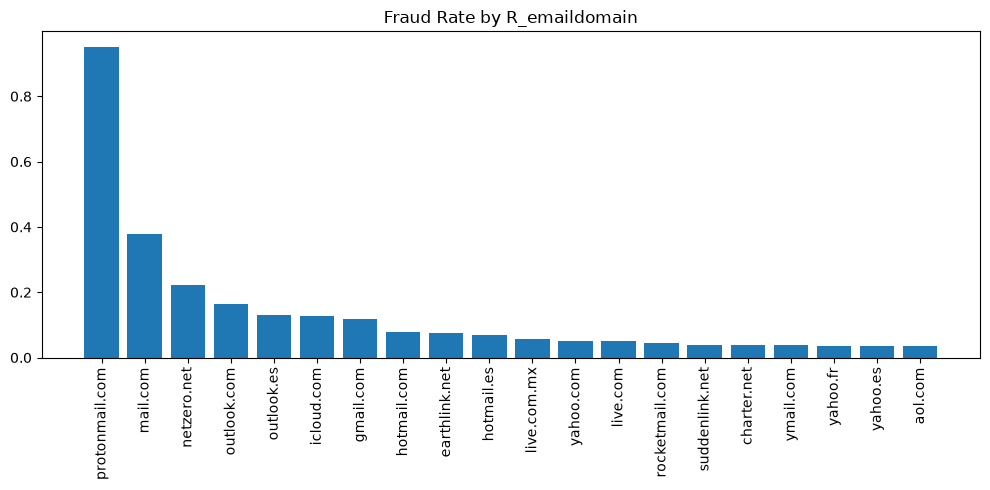

In [11]:
email_cols = ["P_emaildomain", "R_emaildomain"]
for col in email_cols:
    summary = (
        df.groupby(col)["isFraud"]
        .agg(["count", "sum", "mean"])
        .rename(columns={"mean":"Fraud Rate"})
        .sort_values(by="Fraud Rate", ascending=False)
        .head(20)
    )

    display(summary)

    plt.figure(figsize=(10,5))

    plt.bar(
        summary.index.astype(str),
        summary["Fraud Rate"]
    )

    plt.title(f"Fraud Rate by {col}")

    plt.xticks(rotation=90)

    plt.tight_layout()

    plt.show()

# Device analysis 
device information provides an important behavioral signal that can be used to identify fraudulent activity. Fraudsters often reuse devices across multiple fraudulent transactions, making device attributes valuable candidates for graph nodes or node features.

This section investigates:

- Device type distribution
- Device information frequency
- Fraud rates by device
- Missing values within device attributes

The insights will help determine whether device-related information should be represented as graph entities during graph construction.



DEVICE ANALYSIS
----- DeviceType-----


DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64

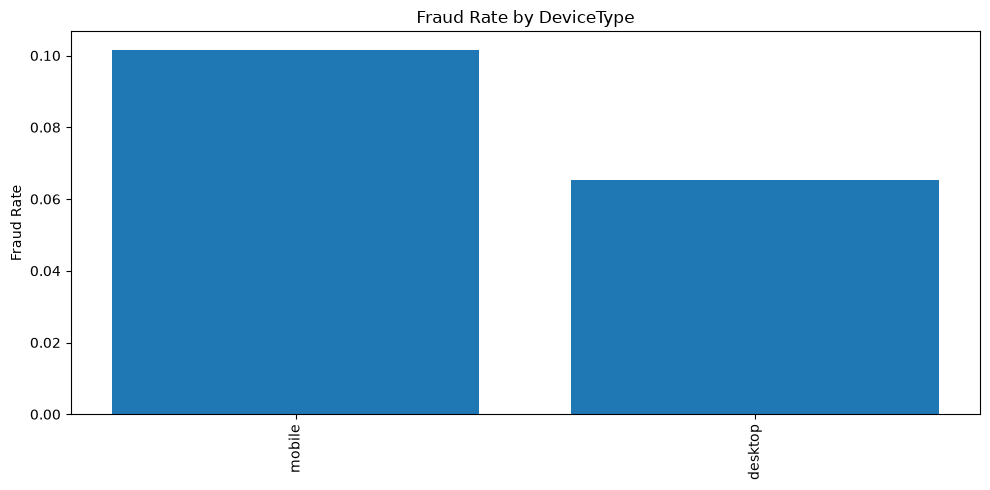

----- DeviceInfo-----


DeviceInfo
NaN                            471874
Windows                         47722
iOS Device                      19782
MacOS                           12573
Trident/7.0                      7440
rv:11.0                          1901
rv:57.0                           962
SM-J700M Build/MMB29K             549
SM-G610M Build/MMB29K             461
SM-G531H Build/LMY48B             410
rv:59.0                           362
SM-G935F Build/NRD90M             334
SM-G955U Build/NRD90M             328
SM-G532M Build/MMB29T             316
ALE-L23 Build/HuaweiALE-L23       312
SM-G950U Build/NRD90M             290
SM-G930V Build/NRD90M             274
rv:58.0                           269
rv:52.0                           256
SAMSUNG                           235
Name: count, dtype: int64

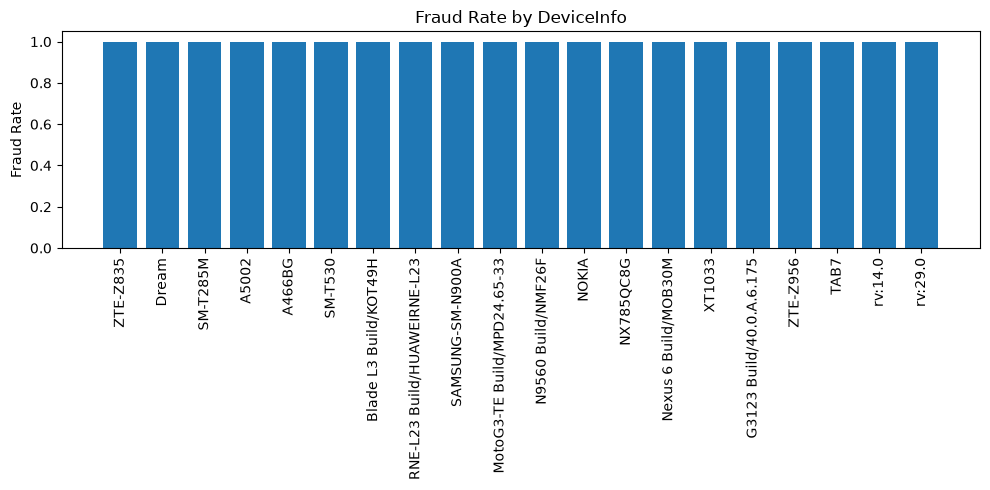

In [12]:
print("="*70)
print("DEVICE ANALYSIS")
print("="*70)

device_cols = ["DeviceType", "DeviceInfo"]

for col in device_cols:

    if col not in df.columns:
        print(f"{col} not found in the dataset.")
        continue

    print(f"----- {col}-----")

    display(df[col].value_counts(dropna=False).head(20))

    fraud_rate = (
        df.groupby(col)["isFraud"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10,5))

    plt.bar(
        fraud_rate.index.astype(str),
        fraud_rate.values
    )

    plt.title(f"Fraud Rate by {col}")
    plt.ylabel("Fraud Rate")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 14. Identity Feature Analysis

Identity-related attributes provide additional contextual information that may distinguish fraudulent users from legitimate ones.

This section explores selected identity variables, evaluates their completeness, and assesses whether they may contribute useful predictive information.

In [13]:
identity_features = [
    "id_01", "id_02", "id_03", "id_05", "id_30", "id_31", "id_33"
]

available_features = [col for col in identity_features if col in df.columns]

for col in available_features:

    print("="*60)
    print(col)

    display(df[col].describe())

    missing = df[col].isnull().mean() * 100

    print(f"Missing Values: {missing:.2f}%")


id_01


count    144233.000000
mean        -10.170502
std          14.347949
min        -100.000000
25%         -10.000000
50%          -5.000000
75%          -5.000000
max           0.000000
Name: id_01, dtype: float64

Missing Values: 75.58%
id_02


count    140872.000000
mean     174716.584708
std      159651.816856
min           1.000000
25%       67992.000000
50%      125800.500000
75%      228749.000000
max      999595.000000
Name: id_02, dtype: float64

Missing Values: 76.15%
id_03


...

Missing Values: 86.87%
id_31


count          140282
unique            130
top       chrome 63.0
freq            22000
Name: id_31, dtype: object

Missing Values: 76.25%
id_33


count         73289
unique          260
top       1920x1080
freq          16874
Name: id_33, dtype: object

Missing Values: 87.59%


# 15. Correlation Analysis

Correlation analysis helps identify relationships between numerical variables and may reveal redundant features or useful interactions.

Although Graph Neural Networks rely less on traditional feature correlations than tabular models, understanding these relationships remains valuable for feature engineering.

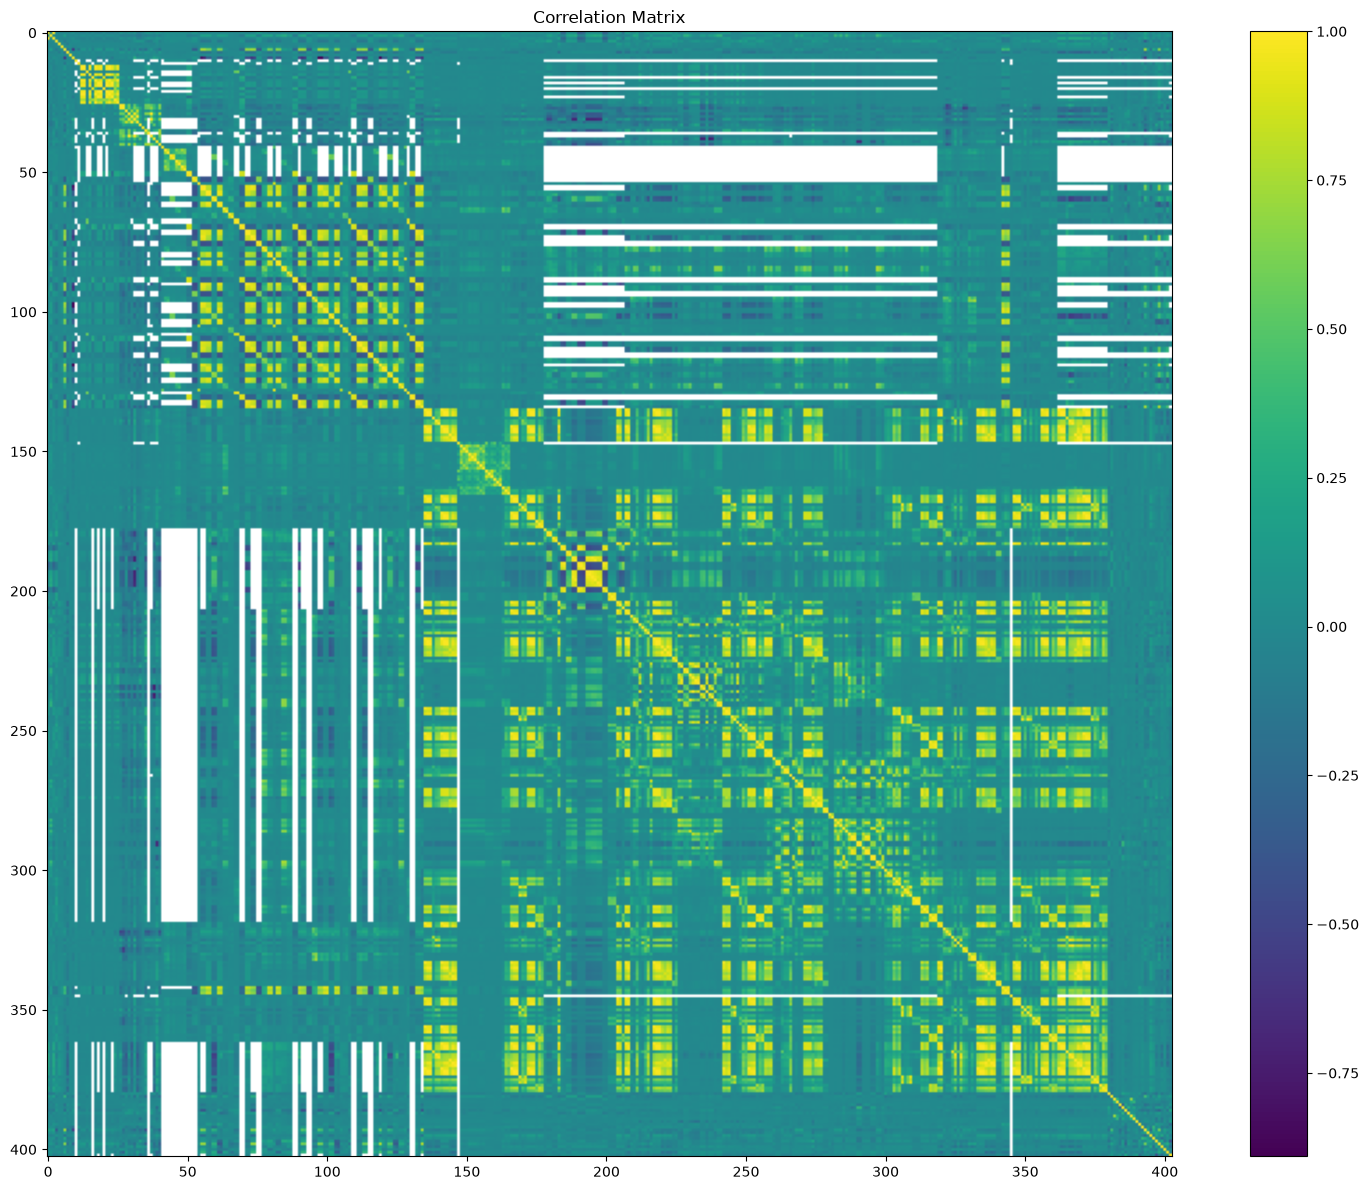

In [14]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(16,12))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 16. Outlier Detection

Fraudulent transactions often exhibit unusually large or unusually small transaction amounts.

This section investigates potential outliers within the transaction amount distribution.

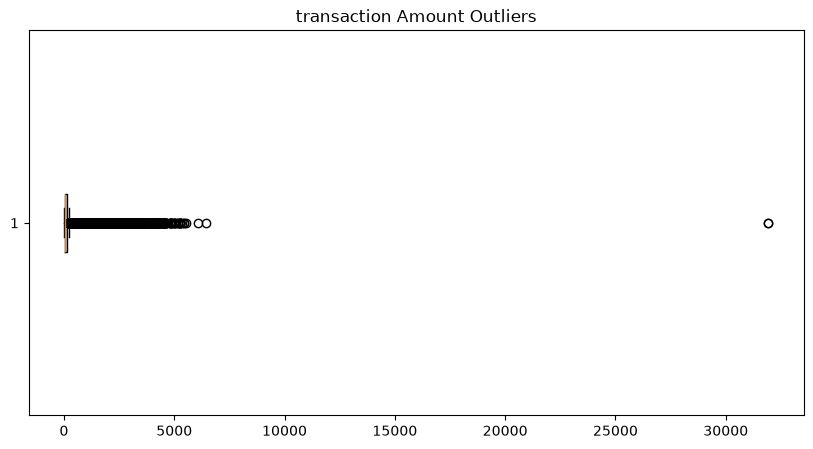

Detected outliers: 66,482


In [15]:
plt.figure(figsize=(10,5))

plt.boxplot(
    df["TransactionAmt"],
    vert=False
)

plt.title("transaction Amount Outliers")

plt.show()

q1 = df["TransactionAmt"].quantile(0.25)
q3 = df["TransactionAmt"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["TransactionAmt"] < lower) | (df["TransactionAmt"] > upper)]

print(f"Detected outliers: {len(outliers):,}")

# 17. High Cardinality Analysis

High-cardinality features contain many unique values and require careful handling during preprocessing.

Understanding these features helps determine whether they should become graph nodes, embeddings, or engineered features.

In [16]:
cardinality = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().mean()*100
})

cardinality = cardinality.sort_values(by="Unique Values", ascending=False)

display(cardinality.head(30))

,Unique Values,Missing Values
TransactionID,590540,0.000000
TransactionDT,573349,0.000000
id_02,115655,76.145223
V307,37367,0.002032
V127,24414,0.053172
V308,23064,0.002032
TransactionAmt,20902,0.000000
V310,19136,0.002032
V306,16210,0.002032
V317,15184,0.002032


# 18. Feature Importance Candidates

Before training any model, it is useful to identify features that appear likely to contribute to fraud detection.

These candidates are selected based on domain knowledge and exploratory analysis rather than model-derived importance scores.

In [17]:
candidate_features = [
    "TransactionAmt",
    "ProductCD",
    "card1",
    "card2",
    "card4",
    "card4",

    "card6",

    "addr1",

    "addr2",

    "DeviceType",

    "DeviceInfo",

    "P_emaildomain",

    "R_emaildomain"

]

candidate_features = [

    col for col in candidate_features

    if col in df.columns

]

display(

    df[candidate_features].head()

)

,TransactionAmt,ProductCD,card1,card2,card4,card4,card6,addr1,addr2,DeviceType,DeviceInfo,P_emaildomain,R_emaildomain
0,68.5,W,13926,NaN,discover,discover,credit,315.0,87.0,NaN,NaN,NaN,NaN
1,29.0,W,2755,404.0,mastercard,mastercard,credit,325.0,87.0,NaN,NaN,gmail.com,NaN
2,59.0,W,4663,490.0,visa,visa,debit,330.0,87.0,NaN,NaN,outlook.com,NaN
3,50.0,W,18132,567.0,mastercard,mastercard,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN
4,50.0,H,4497,514.0,mastercard,mastercard,credit,420.0,87.0,mobile,SAMSUNG SM-G892A Build/NRD90M,gmail.com,NaN


# 19. Candidate Graph Entities

The following dataset attributes have been identified as potential graph entities.

These entities will become nodes within the heterogeneous graph.

In [18]:
graph_entities = pd.DataFrame({

    "Dataset Column":[

        "TransactionID",

        "card1",

        "DeviceInfo",

        "DeviceType",

        "addr1",

        "P_emaildomain"

    ],

    "Graph Entity":[

        "Transaction",

        "Card",

        "Device Fingerprint",

        "Device Type",

        "Address",

        "Email Domain"

    ],

    "Reason":[

        "Prediction target",

        "Payment instrument",

        "Device identity",

        "Device classification",

        "Regional behaviour",

        "Customer identity"

    ]

})

display(graph_entities)

,Dataset Column,Graph Entity,Reason
0,TransactionID,Transaction,Prediction target
1,card1,Card,Payment instrument
2,DeviceInfo,Device Fingerprint,Device identity
3,DeviceType,Device Type,Device classification
4,addr1,Address,Regional behaviour
5,P_emaildomain,Email Domain,Customer identity


# 20. Candidate Graph Relationships

Relationships define how graph entities interact.

These relationships will become edges during graph construction.

In [19]:
graph_edges = pd.DataFrame({

    "Source":[

        "Customer",

        "Customer",

        "Transaction",

        "Transaction",

        "Transaction",

        "Transaction"

    ],

    "Relationship":[

        "owns",

        "initiates",

        "uses",

        "occurs_at",

        "originates_from",

        "originates_from"

    ],

    "Destination":[

        "Card",

        "Transaction",

        "Card",

        "Merchant",

        "Device",

        "IP Address"

    ]

})

display(graph_edges)

,Source,Relationship,Destination
0,Customer,owns,Card
1,Customer,initiates,Transaction
2,Transaction,uses,Card
3,Transaction,occurs_at,Merchant
4,Transaction,originates_from,Device
5,Transaction,originates_from,IP Address


# 21. Feature Engineering Opportunities

The exploratory analysis suggests several opportunities for constructing informative features.

These engineered variables will enrich node representations before graph construction.

In [20]:
feature_engineering = pd.DataFrame({

    "Candidate Feature":[

        "Transaction Frequency",

        "Average Spend",

        "Device Reuse Count",

        "Card Usage Count",

        "Merchant Fraud Rate",

        "Email Domain Frequency",

        "Time Since Previous Transaction"

    ],

    "Purpose":[

        "Customer behaviour",

        "Customer profile",

        "Device risk",

        "Card behaviour",

        "Merchant behaviour",

        "Identity behaviour",

        "Temporal behaviour"

    ]

})

display(feature_engineering)

,Candidate Feature,Purpose
0,Transaction Frequency,Customer behaviour
1,Average Spend,Customer profile
2,Device Reuse Count,Device risk
3,Card Usage Count,Card behaviour
4,Merchant Fraud Rate,Merchant behaviour
5,Email Domain Frequency,Identity behaviour
6,Time Since Previous Transaction,Temporal behaviour


# 22. Graph Construction Insights

The exploratory analysis supports modelling the fraud detection problem as a heterogeneous graph.

Transactions will serve as the prediction targets, while customers, cards, merchants, devices, and IP addresses provide the surrounding relational context used by the Graph Neural Network.

In [21]:
graph_summary = pd.DataFrame({

    "Component":[

        "Graph Type",

        "Prediction Task",

        "Primary GNN",

        "Framework",

        "Prediction Node"

    ],

    "Selection":[

        "Heterogeneous Graph",

        "Binary Node Classification",

        "GraphSAGE",

        "PyTorch Geometric",

        "Transaction"

    ]

})

display(graph_summary)

,Component,Selection
0,Graph Type,Heterogeneous Graph
1,Prediction Task,Binary Node Classification
2,Primary GNN,GraphSAGE
3,Framework,PyTorch Geometric
4,Prediction Node,Transaction


# 23. Conclusions

This exploratory analysis revealed several characteristics that directly influence the design of the Graph Fraud Detection System.

## Key Findings

- The dataset exhibits severe class imbalance.
- Transaction amount contains substantial outliers and benefits from transformation.
- Device and identity attributes provide valuable contextual information despite missing values.
- Several categorical variables exhibit high cardinality, making them strong candidates for graph entities or learned embeddings.
- Relationships between transactions, cards, devices, merchants, and customers naturally support a heterogeneous graph representation.